<a href="https://colab.research.google.com/github/SHolic/AI-course/blob/main/DFS_BFS_UCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**COSC-4117EL Fall 2023**

This is the implementation of three search algorithms: Depth First Search (DFS), Breadth First Search (BFS), and Uniform Cost Search (UCS) on a directed graph.



Import libraries

matplotlib: https://matplotlib.org/

networkx: https://networkx.org/documentation/stable/tutorial.html

queue: https://docs.python.org/3.10/library/queue.html


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import queue

Define the directed graph:
Graph class is implemented with the ability to add edges with associated costs.

add_edge: Adds an edge to the graph with an associated cost. If the start node does not exist in the graph, it initializes it.

get_neighbors: Returns neighbors (and associated costs) of a given node.

In [ ]:
class Graph:
    def __init__(self):
        # Dictionary to store nodes and their neighbors
        self.nodes = {}

    def add_edge(self, start, end, cost=1):
        """Add an edge to the graph from 'start' to 'end' with a given 'cost'."""

        # If the starting node is not already in the graph, add it
        if start not in self.nodes:
            self.nodes[start] = {}

        # Add the ending node as a neighbor to the starting node with the given cost
        self.nodes[start][end] = cost

    def get_neighbors(self, node):
        """Return the neighbors of the given 'node'."""
        return self.nodes.get(node, {})

Implement the search algorithms

dfs: Depth First Search is implemented using a stack. It searches deeper into the graph before backtracking.

bfs: Breadth First Search is implemented using a queue. It searches all neighbors at the present depth before moving on to nodes at the next depth level.

ucs: Uniform Cost Search is implemented using a priority queue. It always selects the node with the lowest cost to expand next.

In [ ]:
def dfs(graph, start, goal):
    """Depth First Search implementation."""
    # Initialize the stack with the starting node, path and cost
    stack = queue.LifoQueue()
    stack.put((start, [start], 0))

    while not stack.empty():
        vertex, path, cost = stack.get()
        # Sort neighbors in descending order for LIFO processing
        sorted_neighbors = sorted(graph.get_neighbors(vertex).items(), key=lambda x: x[0], reverse=True)

        for next_node, next_cost in sorted_neighbors:
            if next_node in path:
                continue
            elif next_node == goal:
                # If the goal node is found, return the path and cost
                return path + [next_node], cost + next_cost
            else:
                stack.put((next_node, path + [next_node], cost + next_cost))
    # If no path is found, return None for both path and cost
    return None, None

def bfs(graph, start, goal):
    """Breadth First Search implementation."""
    # Initialize the queue with the starting node, path and cost
    q = queue.Queue()
    q.put((start, [start], 0))

    while not q.empty():
        vertex, path, cost = q.get()
        # Sort neighbors in ascending order for FIFO processing
        sorted_neighbors = sorted(graph.get_neighbors(vertex).items(), key=lambda x: x[0])

        for next_node, next_cost in sorted_neighbors:
            if next_node in path:
                continue
            elif next_node == goal:
                # If the goal node is found, return the path and cost
                return path + [next_node], cost + next_cost
            else:
                q.put((next_node, path + [next_node], cost + next_cost))
    # If no path is found, return None for both path and cost
    return None, None

def ucs(graph, start, goal):
    """Uniform Cost Search implementation."""
    # Initialize the priority queue with the starting node and cost
    pq = queue.PriorityQueue()
    pq.put((0, start, [start]))

    # Set to keep track of visited nodes
    visited = set()

    while not pq.empty():
        cost, vertex, path = pq.get()

        # If the node has been visited before, skip processing
        if vertex in visited:
            continue
        if vertex == goal:
            # If the goal node is found, return the path and cost
            return path, cost

        visited.add(vertex)

        # For each neighbor of the current node, calculate total cost and add to the queue
        for next_node, next_cost in graph.get_neighbors(vertex).items():
            if next_node not in visited:
                pq.put((cost + next_cost, next_node, path + [next_node]))

    # If no path is found, return None
    return None


Visualize the graph

visualize_graph: Uses NetworkX and Matplotlib to visualize the given graph. Nodes are represented as circles labeled with their names, and edges show the associated costs.
Test and display results:

In [ ]:
def visualize_graph(graph):
    """Visualizes the graph using networkx and matplotlib."""

    G = nx.DiGraph() # Create a directed graph

    # Add edges and their weights to the networkx graph
    for node, neighbors in graph.nodes.items():
        for neighbor, cost in neighbors.items():
            G.add_edge(node, neighbor, weight=cost)

    # Plot settings
    plt.figure(figsize=(3, 3))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=500, node_color="skyblue", node_shape="o", alpha=0.6, linewidths=4)

    # Display edge weights
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.show()


A graph is created and edges are added.
The graph is visualized.
All three search algorithms are run on the graph to find a path from node 'S' to node 'G' and the results are printed.
When you run the code, it should display a visual representation of the graph and the paths (and costs) found by each of the search algorithms.


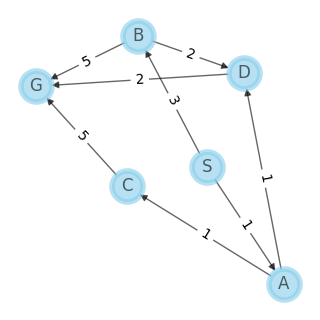

DFS path: ['S', 'A', 'C', 'G'], cost: 7
BFS path: ['S', 'B', 'G'], cost: 8
UCS path: ['S', 'A', 'D', 'G'], cost: 4


In [ ]:
graph = Graph()
# Add the edges from left to right of the tree
graph.add_edge('S', 'A', 1)
graph.add_edge('S', 'B', 3)
graph.add_edge('A', 'C', 1)
graph.add_edge('A', 'D', 1)
graph.add_edge('C', 'G', 5)
graph.add_edge('D', 'G', 2)
graph.add_edge('B', 'D', 2)
graph.add_edge('B', 'G', 5)

# Visualize the graph
visualize_graph(graph)

# Test DFS and print result
path, cost = dfs(graph, 'S', 'G')
print(f"DFS path: {path}, cost: {cost}")

# Test BFS and print result
path, cost = bfs(graph, 'S', 'G')
print(f"BFS path: {path}, cost: {cost}")

# Test UCS and print result
path, cost = ucs(graph, 'S', 'G')
print(f"UCS path: {path}, cost: {cost}")